 # Hydrogeological EDA – Aquifer Water Level Analysis



 This notebook performs a complete exploratory data analysis (EDA) for:



 - Groundwater level (piezometric level)

 - Rainfall

 - Atmospheric pressure

 - Pumping well operational status

 - Earth tide (solid Earth tide components)



 Objectives:



 1. Assess data quality and consistency

 2. Understand statistical properties and distributions

 3. Explore temporal patterns (trend, seasonality, autocorrelation)

 4. Investigate hydrogeological relationships among variables

 5. Support the development of robust forecasting models (ML / DL)

 ## 0. Imports and Initial Configuration

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Time series tools
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use("seaborn-v0_8")
sns.set(font_scale=1.1)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)



 ## 1. Load and Integrate Data



 Expected files (under `BASE_PATH`):



 - `nivel-pocos_chuva_pressao_tratados.csv`

 - `funcionamento_pocos_30min.csv`

 - `earth_tide.csv`

In [2]:
# ======================================================
# 1. Load and integrate data
# ======================================================
BASE_PATH = "."

path_level_rain_pressure = os.path.join(
    BASE_PATH, "data/nivel-pocos_chuva_pressao_tratados.csv"
)
path_wells_func = os.path.join(
    BASE_PATH, "data/funcionamento_pocos_30min.csv"
)
path_earth_tide = os.path.join(
    BASE_PATH, "data/earth_tide.csv"
)

level_rain_pressure = pd.read_csv(path_level_rain_pressure)
wells_func = pd.read_csv(path_wells_func)
earth_tide = pd.read_csv(path_earth_tide)

# ------------------------------------------------------
# Standardize datetime column
# ------------------------------------------------------
if "datetime" in earth_tide.columns:
    earth_tide = earth_tide.rename(columns={"datetime": "date_time"})

for df_ in [level_rain_pressure, wells_func, earth_tide]:
    if "date_time" not in df_.columns:
        raise ValueError("Dataset missing 'date_time' column.")

# ------------------------------------------------------
# Rename variables (standard naming)
# ------------------------------------------------------
rename_map = {
    "pressao_mH2O_final": "pressao_mH2O_final",
    "gmu_level_mH2O_compensado": "gmu_level_mH2O_compensado",
    "chuva_mm_30min": "chuva_mm_30min",
    "status_IMECC": "status_IMECC",
    "status_ZOOLOGIA": "status_ZOOLOGIA",
}

level_rain_pressure = level_rain_pressure.rename(columns=rename_map)
wells_func = wells_func.rename(columns=rename_map)

# ------------------------------------------------------
# Clean pumping status
# ------------------------------------------------------
wells_func = wells_func.dropna()
status_cols = wells_func.columns.difference(["date_time"])
wells_func[status_cols] = wells_func[status_cols].astype(int)

# ------------------------------------------------------
# Merge all datasets
# ------------------------------------------------------
data = (
    level_rain_pressure
    .merge(wells_func, on="date_time", how="outer")
    .merge(earth_tide, on="date_time", how="outer")
)

data["date_time"] = pd.to_datetime(data["date_time"])
data = data.sort_values("date_time").reset_index(drop=True)

print("Merged dataset shape:", data.shape)

Merged dataset shape: (70080, 8)


In [3]:
summary = []

for col in data.columns:
    if col == "date_time":
        continue

    mask = data[col].notna()

    if mask.any():
        times = data.loc[mask, "date_time"]
        summary.append({
            "column": col,
            "first_valid_date_time": times.iloc[times.values.argmin()],
            "last_valid_date_time": times.iloc[times.values.argmax()],
            "n_valid": mask.sum()
        })

summary_df = pd.DataFrame(summary).sort_values("first_valid_date_time")
summary_df

,column,first_valid_date_time,last_valid_date_time,n_valid
6,earth_tide_nm/s2,2022-01-01 00:00:00,2025-12-30 23:30:00,70080
3,status_IMECC,2022-01-01 07:00:00,2025-08-30 14:00:00,64191
4,status_FEF,2022-01-01 07:00:00,2025-08-30 14:00:00,64191
5,status_ZOOLOGIA,2022-01-01 07:00:00,2025-08-30 14:00:00,64191
0,pressao_mH2O_final,2022-04-18 00:00:00,2025-08-14 16:00:00,58305
2,chuva_mm_30min,2022-04-18 00:00:00,2025-08-14 16:00:00,58305
1,gmu_level_mH2O_compensado,2022-04-19 11:00:00,2025-08-14 16:00:00,36717


In [4]:
# %%
# ------------------------------------------------------
# Identify continuous data periods based on real time gaps
# ------------------------------------------------------

column_name = "gmu_level_mH2O_compensado"
expected_freq = pd.Timedelta("30T")  # expected sampling interval

# ------------------------------------------------------
# Ensure datetime index
# ------------------------------------------------------
if "date_time" in data.columns:
    df_ts = data.set_index("date_time").sort_index()
else:
    df_ts = data.copy()

if column_name not in df_ts.columns:
    raise KeyError(f"Column '{column_name}' not found")

# ------------------------------------------------------
# Select valid data
# ------------------------------------------------------
series = df_ts[column_name].dropna()

if series.empty:
    print(f"No valid data for column '{column_name}'.")
else:
    # Compute time differences
    dt = series.index.to_series().diff()

    # Identify breaks (any gap larger than expected)
    breaks = dt > expected_freq

    # Assign group IDs
    group_id = breaks.cumsum()

    periods = []

    for _, group in series.groupby(group_id):
        start = group.index.min()
        end = group.index.max()
        n_points = len(group)
        duration_days = (end - start).total_seconds() / 86400

        periods.append({
            "start": start,
            "end": end,
            "n_points": n_points,
            "duration_days": duration_days
        })

    periods_df = (
        pd.DataFrame(periods)
        .sort_values("start", ascending=True)  # do mais antigo para o mais novo
        .reset_index(drop=True)
    )


    print(f"Continuous periods detected for '{column_name}':")
    display(periods_df)


Continuous periods detected for 'gmu_level_mH2O_compensado':


C:\Users\peliz\AppData\Local\Temp\ipykernel_26120\3972811250.py:7: FutureWarning: 'T' is deprecated and will be removed in a future version. Please use 'min' instead of 'T'.
  expected_freq = pd.Timedelta("30T")  # expected sampling interval


,start,end,n_points,duration_days
0,2022-04-19 11:00:00,2022-04-29 09:00:00,477,9.916667
1,2022-05-11 15:30:00,2022-07-11 11:00:00,2920,60.812500
2,2022-07-18 11:00:00,2022-09-13 16:00:00,2747,57.208333
3,2022-09-14 16:30:00,2022-09-27 16:00:00,624,12.979167
4,2022-10-06 15:30:00,2022-10-17 15:30:00,529,11.000000
5,2022-10-20 16:00:00,2022-10-25 07:00:00,223,4.625000
6,2022-11-03 15:00:00,2022-12-01 15:00:00,1345,28.000000
7,2022-12-15 16:30:00,2023-01-18 15:00:00,1630,33.937500
8,2023-02-07 18:00:00,2023-02-09 09:00:00,79,1.625000
9,2023-02-09 15:30:00,2023-02-24 15:30:00,721,15.000000


In [5]:
# ======================================================
# 2. Select analysis period (SUBSET)
# ======================================================
START_DATE = "2024-12-08 23:00:00"
END_DATE   = "2025-08-14 16:00:00"

filtered_data = data[
    (data["date_time"] >= START_DATE) &
    (data["date_time"] <= END_DATE)
].copy()

print(f"Using period {START_DATE} → {END_DATE}")
print("Filtered shape:", filtered_data.shape)

# ------------------------------------------------------
# Time-indexed version (THIS IS THE CANONICAL OBJECT)
# ------------------------------------------------------
data_ts = (
    filtered_data
    .set_index("date_time")
    .sort_index()
)

print("Time-indexed data shape:", data_ts.shape)

Using period 2024-12-08 23:00:00 → 2025-08-14 16:00:00
Filtered shape: (11939, 8)
Time-indexed data shape: (11939, 7)


 ## 2. Data Quality Assessment



 Includes:



 - Missing values

 - Duplicates

 - Value ranges (sanity checks)

 - Time gaps and frequency irregularities

 ### 2.1 General overview and data types

In [6]:
print("\nGeneral info (filtered period):")
data_ts.info()

print("\nDescriptive statistics (numeric variables) – filtered period:")

# estatísticas descritivas
desc = data_ts.describe().T

# completude
n_total = len(data_ts)
completeness = (
    data_ts.notna().sum() / n_total * 100
).rename("completeness_%")

# junta tudo
summary = desc.join(completeness)

# renomeia APENAS para visualização
rename_map = {
    "pressao_mH2O_final": "baro_ig_mH2O",
    "gmu_level_mH2O_compensado": "gmu_gwl_mH2O",
    "chuva_mm_30min": "rain_mm_30min",
    "status_IMECC": "status_IMECC",
    "status_FEF": "status_FEF",
    "status_ZOOLOGIA": "status_ZOOLOGIA",
    "earth_tide_nm/s2": "earth_tide_nm/s2",
}

summary = summary.rename(index=rename_map)

display(summary)



General info (filtered period):
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 11939 entries, 2024-12-08 23:00:00 to 2025-08-14 16:00:00
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   pressao_mH2O_final         11939 non-null  float64
 1   gmu_level_mH2O_compensado  11939 non-null  float64
 2   chuva_mm_30min             11939 non-null  float64
 3   status_IMECC               11939 non-null  float64
 4   status_FEF                 11939 non-null  float64
 5   status_ZOOLOGIA            11939 non-null  float64
 6   earth_tide_nm/s2           11939 non-null  float64
dtypes: float64(7)
memory usage: 746.2 KB

Descriptive statistics (numeric variables) – filtered period:


,count,mean,std,min,25%,50%,75%,max,completeness_%
baro_ig_mH2O,11939.0,9.655361,0.044706,9.447105,9.628036,9.654880,9.687320,9.762408,100.0
gmu_gwl_mH2O,11939.0,0.372593,2.779303,-3.499775,-2.169084,-0.585697,3.317544,4.810575,100.0
rain_mm_30min,11939.0,0.054250,0.641492,0.000000,0.000000,0.000000,0.000000,37.336000,100.0
status_IMECC,11939.0,0.564369,0.495860,0.000000,0.000000,1.000000,1.000000,1.000000,100.0
status_FEF,11939.0,0.413686,0.492514,0.000000,0.000000,0.000000,1.000000,1.000000,100.0
status_ZOOLOGIA,11939.0,0.561689,0.496201,0.000000,0.000000,1.000000,1.000000,1.000000,100.0
earth_tide_nm/s2,11939.0,-147.720349,685.254853,-2052.088000,-631.014500,-41.082000,385.733000,1107.314000,100.0


 ### 2.2 Missing values

Missing values per column (filtered period):


,missing_count,missing_percent
pressao_mH2O_final,0,0.0
gmu_level_mH2O_compensado,0,0.0
chuva_mm_30min,0,0.0
status_IMECC,0,0.0
status_FEF,0,0.0
status_ZOOLOGIA,0,0.0
earth_tide_nm/s2,0,0.0


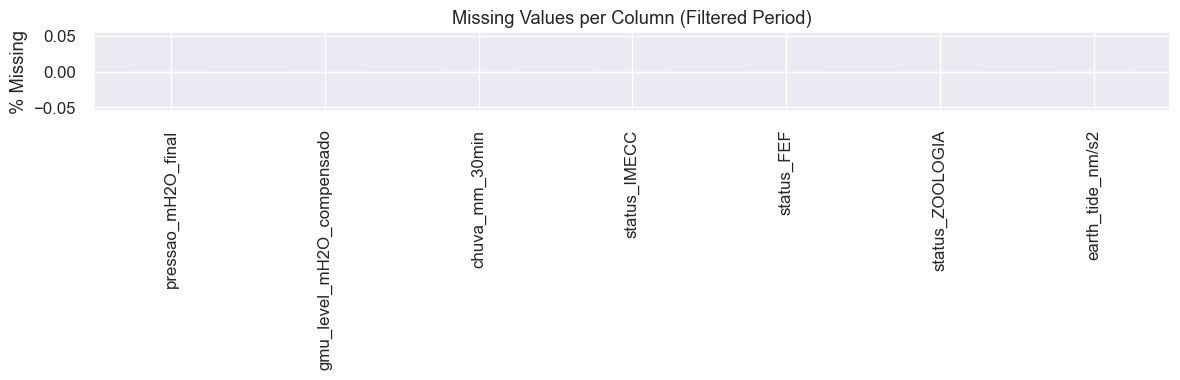

In [7]:
missing_counts = data_ts.isna().sum()
missing_percent = (missing_counts / len(data_ts)) * 100

missing_df = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent
}).sort_values("missing_percent", ascending=False)

print("Missing values per column (filtered period):")
display(missing_df.head(30))

plt.figure(figsize=(12, 4))
missing_percent.plot(kind="bar")
plt.ylabel("% Missing")
plt.title("Missing Values per Column (Filtered Period)")
plt.tight_layout()
plt.show()



 ### 2.3 Duplicate timestamps

In [8]:
duplicates = filtered_data["date_time"].duplicated().sum()
print("Number of duplicated timestamps in filtered period:", duplicates)

if duplicates > 0:
    display(filtered_data[filtered_data["date_time"].duplicated(keep=False)].head())



Number of duplicated timestamps in filtered period: 0


 ### 2.4 Time-series frequency and gaps (Filtered Period Only)

In [9]:
# Use ONLY the filtered and time-indexed series

freq_guess = pd.infer_freq(data_ts.index)
print("Inferred sampling frequency (filtered period):", freq_guess)

# Check for missing timestamps assuming 30-minute interval
expected_freq = "30T"
full_range = pd.date_range(start=data_ts.index.min(), end=data_ts.index.max(), freq=expected_freq)
missing_timestamps = full_range.difference(data_ts.index)

print("Expected timestamps within selected range:", len(full_range))
print("Present timestamps:", len(data_ts))
print("Missing timestamps:", len(missing_timestamps))

if len(missing_timestamps) > 0:
    print("\nExamples of missing timestamps:")
    print(list(missing_timestamps[:20]))



Inferred sampling frequency (filtered period): 30min
Expected timestamps within selected range: 11939
Present timestamps: 11939
Missing timestamps: 0


C:\Users\peliz\AppData\Local\Temp\ipykernel_26120\1766222092.py:8: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_range = pd.date_range(start=data_ts.index.min(), end=data_ts.index.max(), freq=expected_freq)


 ### 2.5 Outlier detection (z-score method)



 Gaps are preserved in the plots (NaNs are kept in the full series so missing periods appear as breaks).

gmu_level_mH2O_compensado: 0 potential outliers (|z| > 3)


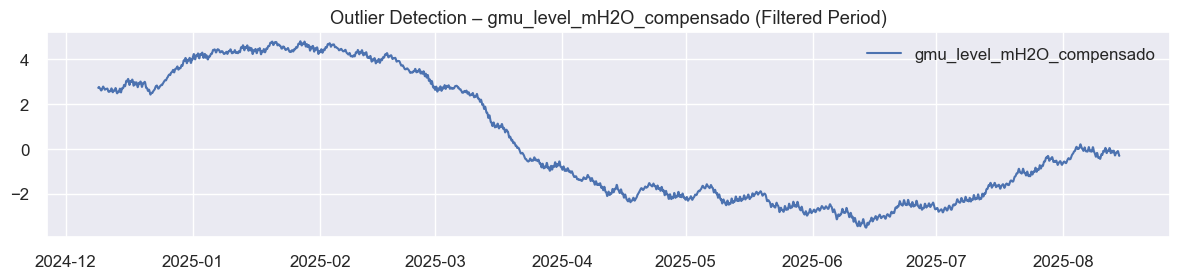

chuva_mm_30min: 82 potential outliers (|z| > 3)


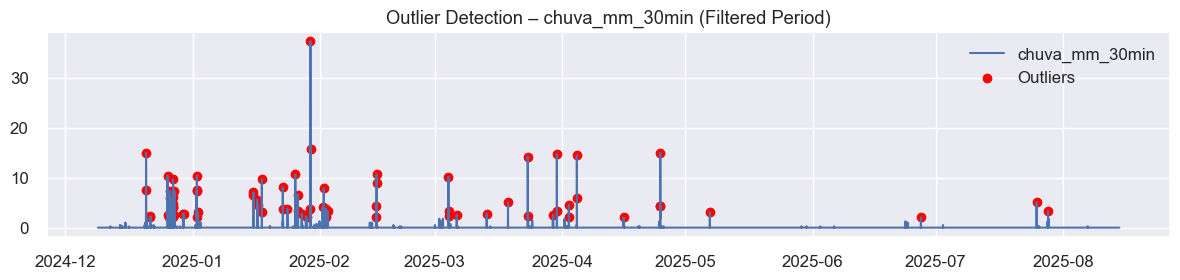

pressao_mH2O_final: 143 potential outliers (|z| > 3)


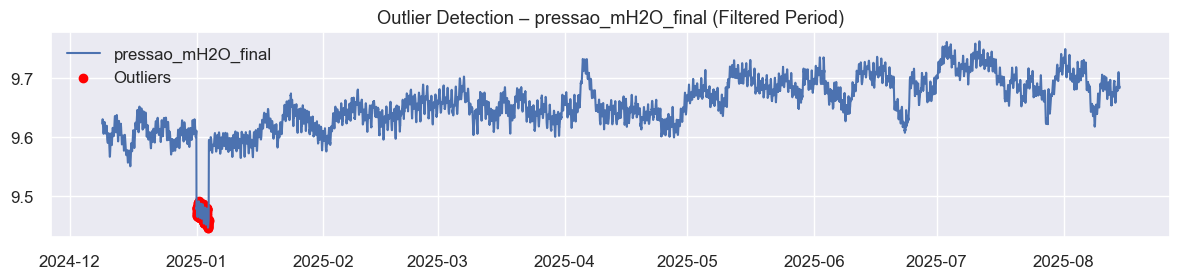

In [10]:
key_cols = [
    col for col in [
        "gmu_level_mH2O_compensado",
        "chuva_mm_30min",
        "pressao_mH2O_final"
    ] if col in data_ts.columns
]

for col in key_cols:
    full_series = data_ts[col]          # keeps NaNs → gaps visible in plot
    series_no_na = full_series.dropna() # used only for z-score

    if series_no_na.empty:
        print(f"{col}: no data available in selected period.")
        continue

    zscores = np.abs(stats.zscore(series_no_na))
    outliers = series_no_na[zscores > 3]

    print(f"{col}: {len(outliers)} potential outliers (|z| > 3)")

    plt.figure(figsize=(12, 3))
    plt.plot(full_series.index, full_series.values, label=col)
    if not outliers.empty:
        plt.scatter(outliers.index, outliers.values, color="red", label="Outliers")
    plt.title(f"Outlier Detection – {col} (Filtered Period)")
    plt.legend()
    plt.tight_layout()
    plt.show()



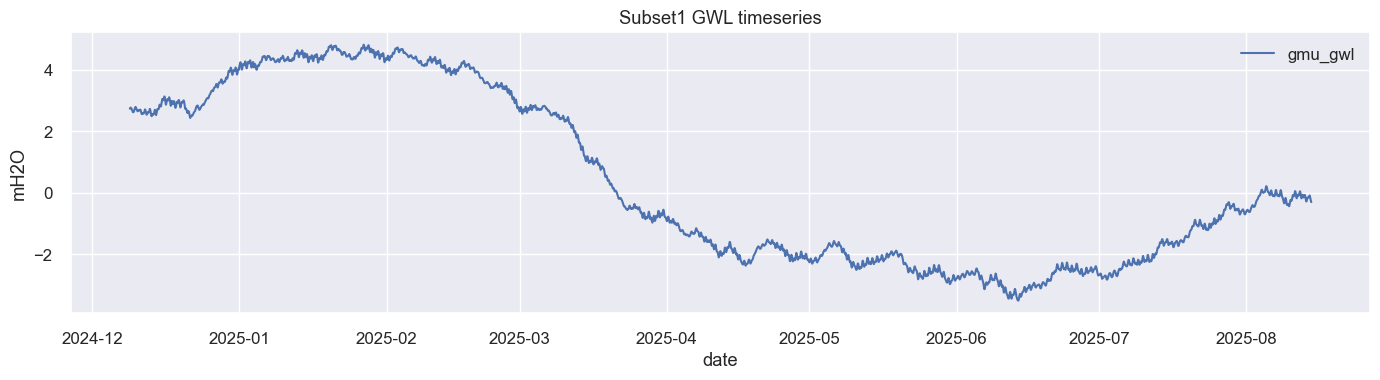

In [11]:
import numpy as np
import matplotlib.pyplot as plt

series = data_ts["gmu_level_mH2O_compensado"]

# 1) mantém apenas valores válidos
series_valid = series.dropna()

t = series_valid.index
y = series_valid.values

# 2) diferença temporal em horas
dt_hours = t.to_series().diff().dt.total_seconds() / 3600

# 3) limiar de gap (use o mesmo critério do barômetro)
gap_threshold_hours = 6   # ajuste se necessário
gap_idx = np.where(dt_hours > gap_threshold_hours)[0]

# 4) força quebra visual
y_plot = y.astype(float).copy()
y_plot[gap_idx] = np.nan

# --- plot ---
plt.figure(figsize=(14, 4))
plt.plot(t, y_plot, label="gmu_gwl")
plt.title("Subset1 GWL timeseries")
plt.ylabel("mH2O")
plt.xlabel("date")
plt.legend()
plt.tight_layout()
plt.show()


### Cleaned time series (NaNs removed) for further analysis

In [12]:
print("Shape before dropna:", data_ts.shape)

data_ts = data_ts.dropna()

print("Shape after dropna :", data_ts.shape)

data_ts.head()


Shape before dropna: (11939, 7)
Shape after dropna : (11939, 7)


,pressao_mH2O_final,gmu_level_mH2O_compensado,chuva_mm_30min,status_IMECC,status_FEF,status_ZOOLOGIA,earth_tide_nm/s2
date_time,,,,,,,
2024-12-08 23:00:00,9.622975,2.733855,0.0,0.0,0.0,0.0,-657.013
2024-12-08 23:30:00,9.624555,2.739275,0.0,0.0,0.0,0.0,-511.472
2024-12-09 00:00:00,9.626134,2.747036,0.0,0.0,0.0,0.0,-345.618
2024-12-09 00:30:00,9.628297,2.750703,0.0,0.0,0.0,0.0,-168.715
2024-12-09 01:00:00,9.630460,2.753790,0.0,0.0,0.0,0.0,9.259


 ## 3. Basic Statistical Analysis & Distribution Exploration



 - Distribution shapes

 - Skewness, kurtosis

 - Histograms and KDE plots

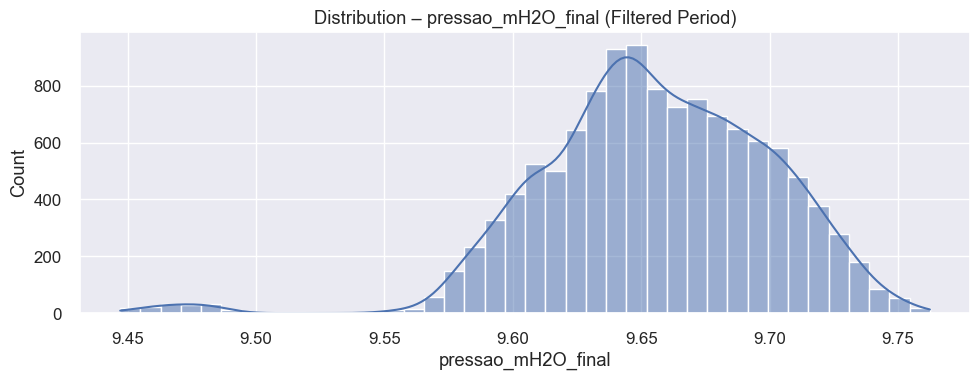

pressao_mH2O_final – Skewness: -0.710, Kurtosis: 2.099
--------------------------------------------------


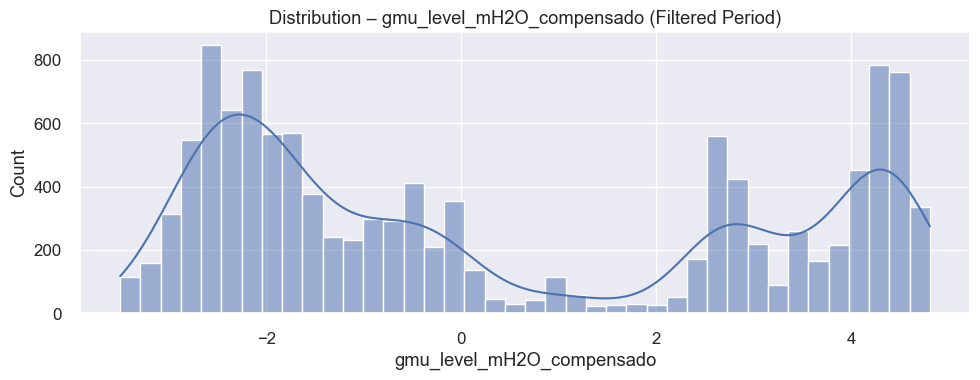

gmu_level_mH2O_compensado – Skewness: 0.342, Kurtosis: -1.536
--------------------------------------------------


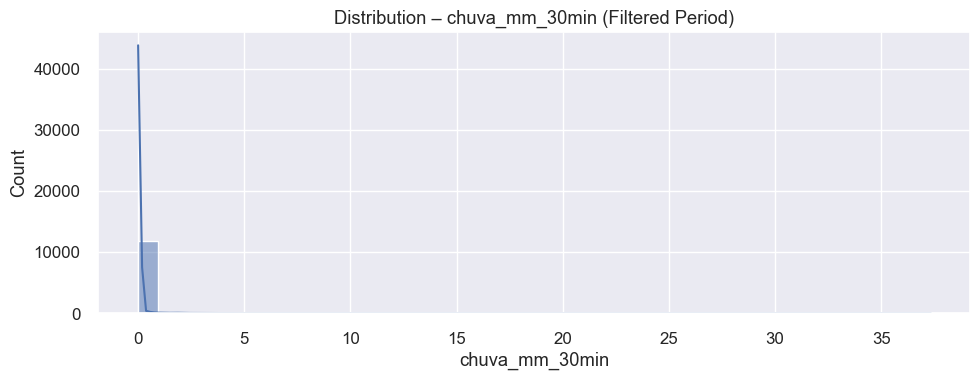

chuva_mm_30min – Skewness: 27.419, Kurtosis: 1158.067
--------------------------------------------------


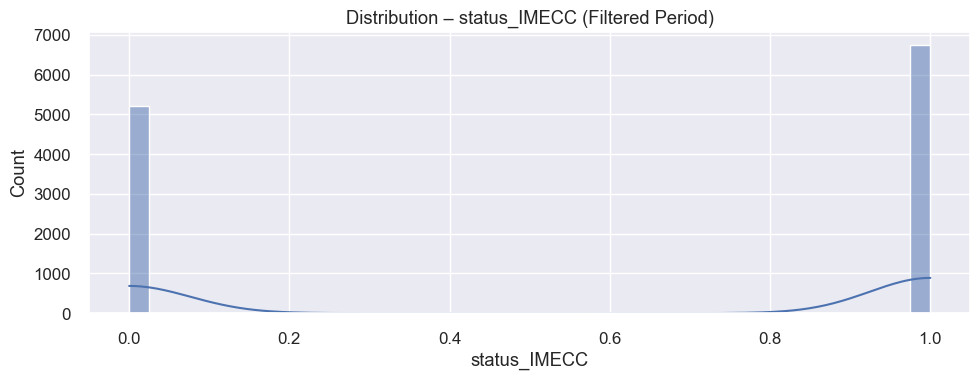

status_IMECC – Skewness: -0.260, Kurtosis: -1.933
--------------------------------------------------


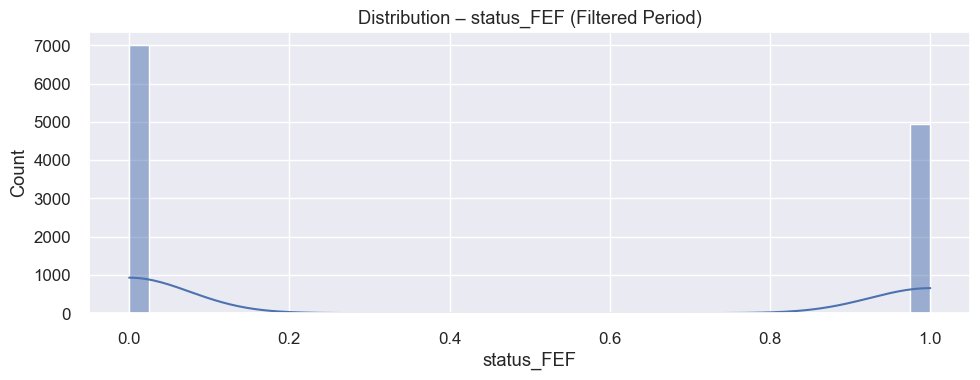

status_FEF – Skewness: 0.351, Kurtosis: -1.877
--------------------------------------------------


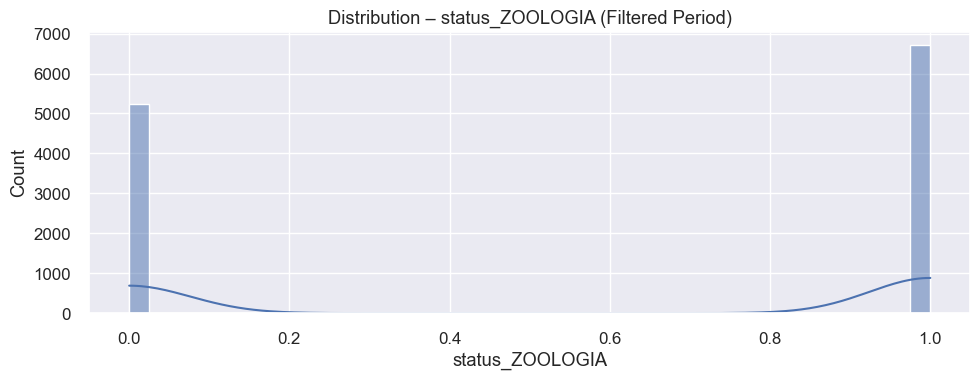

status_ZOOLOGIA – Skewness: -0.249, Kurtosis: -1.938
--------------------------------------------------


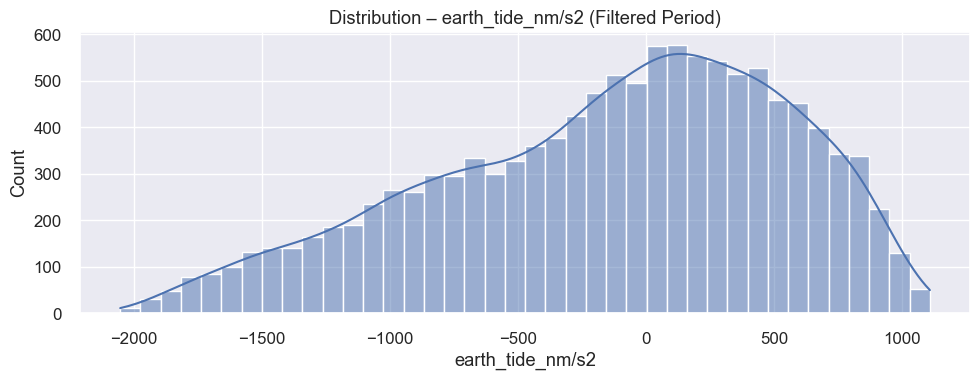

earth_tide_nm/s2 – Skewness: -0.483, Kurtosis: -0.534
--------------------------------------------------


In [13]:
num_cols = data_ts.select_dtypes(include=[np.number]).columns

for col in num_cols:
    series = data_ts[col].dropna()
    if series.empty:
        continue

    plt.figure(figsize=(10, 4))
    sns.histplot(series, kde=True, bins=40)
    plt.title(f"Distribution – {col} (Filtered Period)")
    plt.tight_layout()
    plt.show()

    print(f"{col} – Skewness: {series.skew():.3f}, Kurtosis: {series.kurt():.3f}")
    print("-" * 50)



 ## 4. Time-Series Exploration



 Includes:



 - Trend and seasonal decomposition (STL)

 - Autocorrelation (ACF) and partial autocorrelation (PACF)

 - Temporal plots

 ### 4.1 Time-series plots

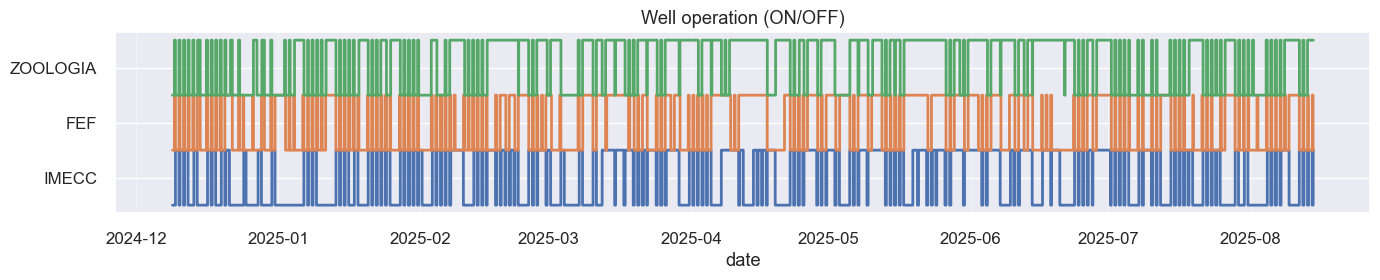

In [14]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(14, 3))

wells = {
    "IMECC": data_ts["status_IMECC"],
    "FEF": data_ts["status_FEF"],
    "ZOOLOGIA": data_ts["status_ZOOLOGIA"]
}

y_base = np.arange(len(wells))

for i, (name, s) in enumerate(wells.items()):
    ax.step(
        s.index,
        s.values + y_base[i],
        where="post",
        linewidth=2,
        label=name
    )

ax.set_yticks(y_base + 0.5)
ax.set_yticklabels(wells.keys())

ax.set_xlabel("date")
ax.set_title("Well operation (ON/OFF)")
ax.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.show()


 ### 4.2 STL decomposition



 Note: This uses the filtered period. For heavily gapped data, a block-wise STL decomposition may be preferable.

C:\Users\peliz\AppData\Local\Temp\ipykernel_26120\4206975423.py:10: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  series = series.asfreq("30T")


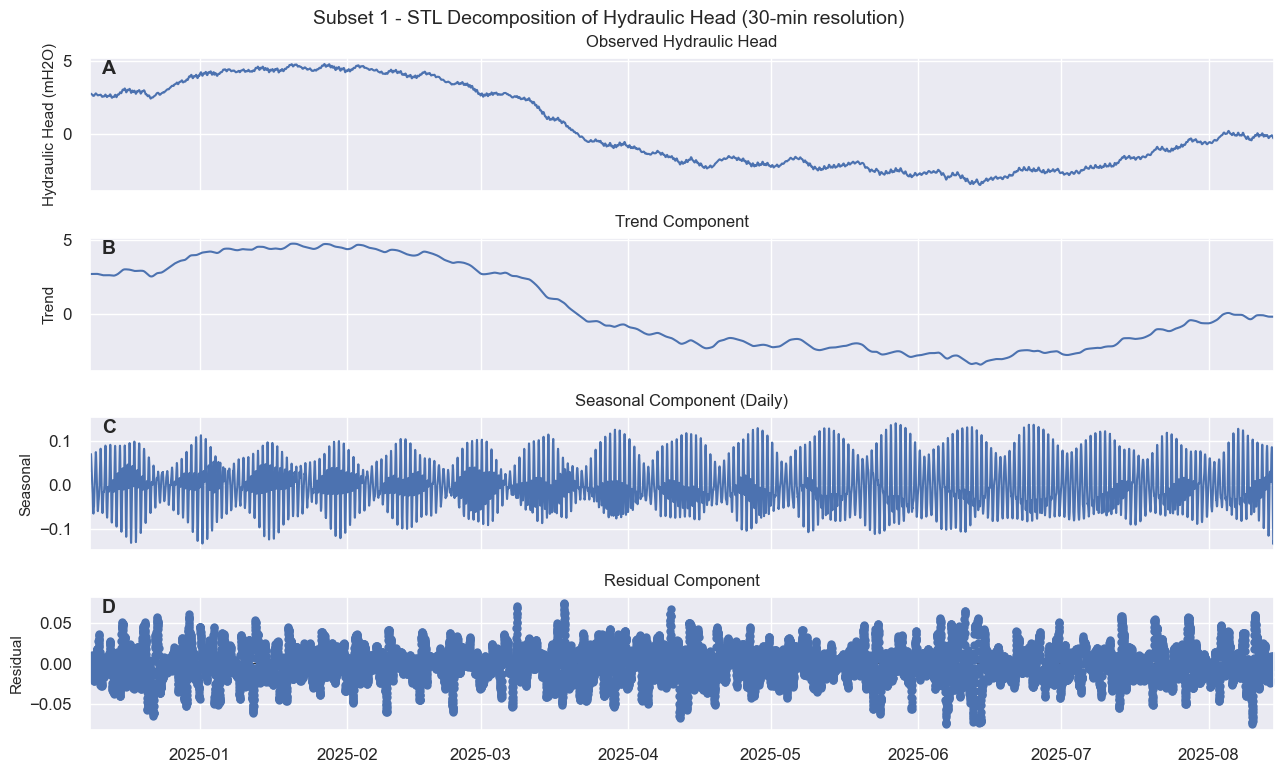

In [15]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

series = data_ts["gmu_level_mH2O_compensado"].dropna()

if series.empty:
    print("No data available for STL decomposition in the selected period.")
else:
    # enforce regular frequency
    series = series.asfreq("30T")

    stl = STL(series, period=48)  # 48 half-hour steps ≈ 1 day
    result = stl.fit()

    # --- custom plot ---
    fig = result.plot()

    # Increase spacing between subplots
    fig.set_size_inches(14, 8)
    fig.subplots_adjust(
        top=0.92,
        bottom=0.08,
        hspace=0.35
    )

    axes = fig.axes

    # Improve axis titles
    axes[0].set_title("Observed Hydraulic Head", fontsize=12, pad=8)
    axes[1].set_title("Trend Component", fontsize=12, pad=8)
    axes[2].set_title("Seasonal Component (Daily)", fontsize=12, pad=8)
    axes[3].set_title("Residual Component", fontsize=12, pad=8)

    # Add y-axis labels
    axes[0].set_ylabel("Hydraulic Head (mH2O)", fontsize=11)
    axes[1].set_ylabel("Trend", fontsize=11)
    axes[2].set_ylabel("Seasonal", fontsize=11)
    axes[3].set_ylabel("Residual", fontsize=11)

    # Optional: bold subplot labels inside each graph
    subplot_labels = ["A", "B", "C", "D"]
    for ax, label in zip(axes, subplot_labels):
        ax.text(
            0.01, 0.88,
            label,
            transform=ax.transAxes,
            fontsize=14,
            fontweight="bold"
        )

    # Global title
    fig.suptitle(
        "Subset 1 - STL Decomposition of Hydraulic Head (30-min resolution)",
        fontsize=14,
        y=0.98
    )

    plt.show()

 ### 4.3 ACF & PACF

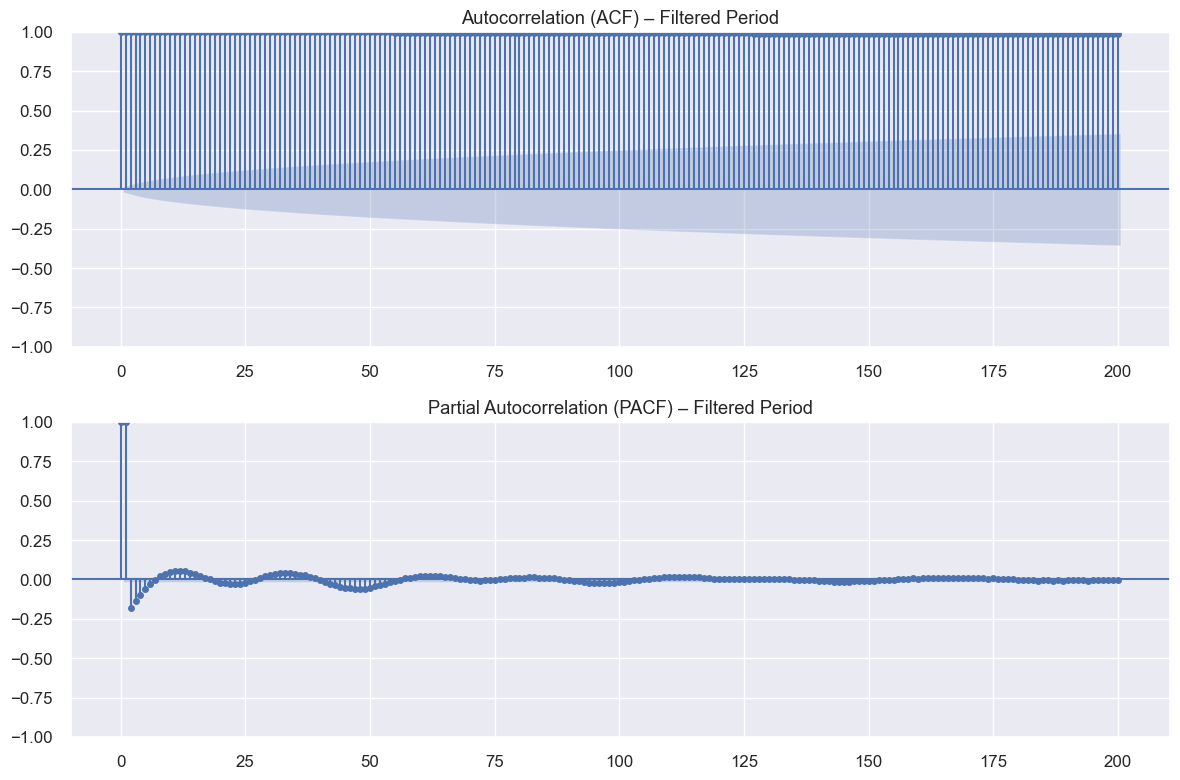

In [16]:
series_acf = data_ts["gmu_level_mH2O_compensado"].dropna()

if series_acf.empty:
    print("No data available for ACF/PACF in the selected period.")
else:
    fig, ax = plt.subplots(2, 1, figsize=(12, 8))

    plot_acf(series_acf, ax=ax[0], lags=200)
    plot_pacf(series_acf, ax=ax[1], lags=200)

    ax[0].set_title("Autocorrelation (ACF) – Filtered Period")
    ax[1].set_title("Partial Autocorrelation (PACF) – Filtered Period")
    plt.tight_layout()
    plt.show()



### 4.4 Explicit Lag Autocorrelation (Level vs Lagged Level)

 This section computes the Pearson correlation between the groundwater level
 and its lagged versions for lags from 1 to 1440 time steps (30-minute intervals).
 This corresponds to autocorrelation up to ~30 days.


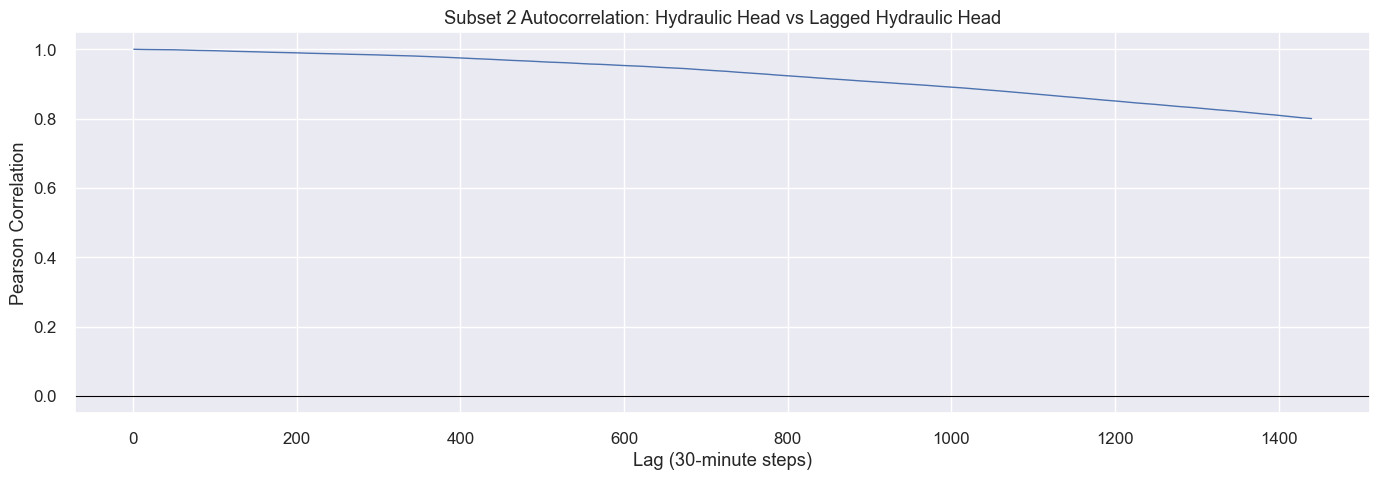

Top 10 lags with highest autocorrelation:


,lag,lag_hours,lag_days,autocorrelation
0,1,0.5,0.020833,0.999992
1,2,1.0,0.041667,0.999970
2,3,1.5,0.062500,0.999935
3,4,2.0,0.083333,0.999888
4,5,2.5,0.104167,0.999832
5,6,3.0,0.125000,0.999769
6,7,3.5,0.145833,0.999702
7,8,4.0,0.166667,0.999633
8,9,4.5,0.187500,0.999564
9,10,5.0,0.208333,0.999498


In [17]:
# Select level series
level_series = data_ts["gmu_level_mH2O_compensado"].dropna()

if level_series.empty:
    print("No data available for lagged autocorrelation analysis.")
else:
    max_lag = 1440  # 1440 * 30 min = 30 days
    autocorr_results = []

    for lag in range(1, max_lag + 1):
        shifted = level_series.shift(lag)

        # Align and drop NaNs caused by shifting
        valid = pd.concat([level_series, shifted], axis=1).dropna()

        if len(valid) < 10:
            corr = np.nan
        else:
            corr = valid.iloc[:, 0].corr(valid.iloc[:, 1])

        autocorr_results.append({
            "lag": lag,
            "lag_hours": lag * 0.5,
            "lag_days": lag / 48,
            "autocorrelation": corr
        })

    autocorr_df = pd.DataFrame(autocorr_results)

    # -----------------------------
    # Plot autocorrelation vs lag
    # -----------------------------
    plt.figure(figsize=(14, 5))
    plt.plot(
        autocorr_df["lag"],
        autocorr_df["autocorrelation"],
        linewidth=1
    )
    plt.axhline(0, color="black", linewidth=0.8)
    plt.xlabel("Lag (30-minute steps)")
    plt.ylabel("Pearson Correlation")
    plt.title("Subset 2 Autocorrelation: Hydraulic Head vs Lagged Hydraulic Head")
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Top 10 lags by autocorrelation
    # -----------------------------
    top_10_lags = (
        autocorr_df
        .dropna()
        .sort_values("autocorrelation", ascending=False)
        .head(10)
    )

    print("Top 10 lags with highest autocorrelation:")
    display(top_10_lags)

In [18]:
from scipy.signal import find_peaks
import numpy as np
import pandas as pd

# Série de autocorrelação
lags = autocorr_df["lag"].values
autocorr_values = autocorr_df["autocorrelation"].values

# Remover NaNs
mask = ~np.isnan(autocorr_values)
lags = lags[mask]
autocorr_values = autocorr_values[mask]

# ----------------------------------------
# Encontrar picos locais
# ----------------------------------------
peaks_idx, properties = find_peaks(
    autocorr_values,
    distance=20,        # mínimo de 20 lags entre picos (≈10 h)
    prominence=0.01     # filtra picos pouco relevantes
)

# Criar DataFrame com os picos
peaks_df = pd.DataFrame({
    "lag": lags[peaks_idx],
    "lag_hours": lags[peaks_idx] * 0.5,
    "lag_days": lags[peaks_idx] / 48,
    "autocorrelation": autocorr_values[peaks_idx]
})

# Ordenar pelos picos mais fortes
peaks_df = peaks_df.sort_values(
    "autocorrelation",
    ascending=False
)

# Top 10 picos
top_10_peaks = peaks_df.head(10)

print("Top 10 lags corresponding to autocorrelation peaks:")
display(top_10_peaks)


Top 10 lags corresponding to autocorrelation peaks:


,lag,lag_hours,lag_days,autocorrelation


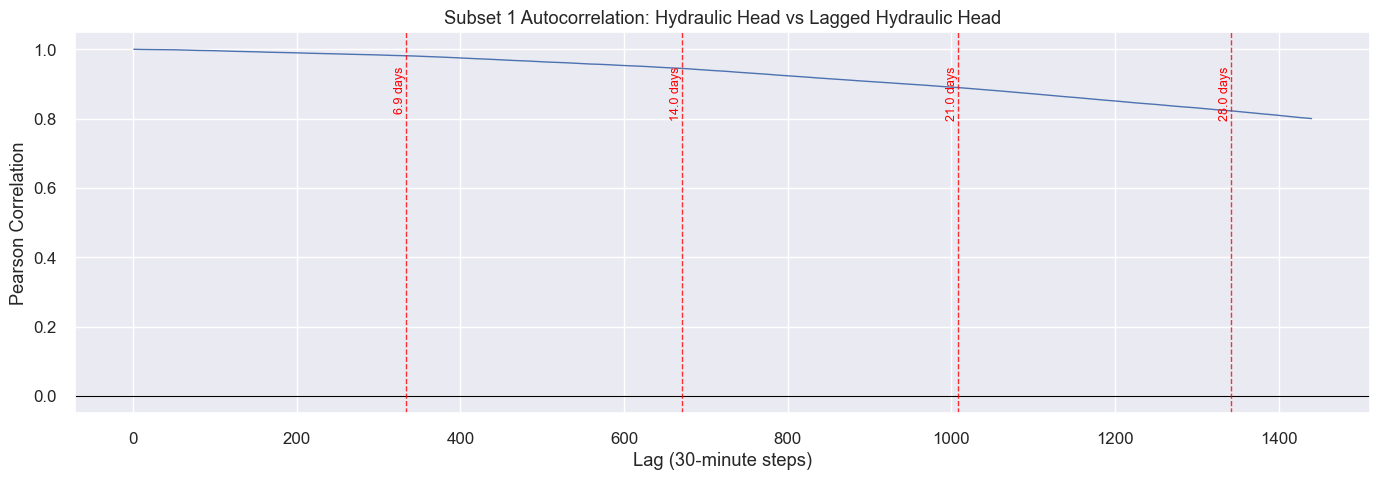

In [19]:
lag1 = 333
lag2 = 671
lag3 = 1008
lag4 = 1342

# -----------------------------
# Plot autocorrelation vs lag
# -----------------------------
plt.figure(figsize=(14, 5))

plt.plot(
    autocorr_df["lag"],
    autocorr_df["autocorrelation"],
    linewidth=1
)

# linha zero
plt.axhline(0, color="black", linewidth=0.8)

# lags a destacar
highlight_lags = [lag1, lag2, lag3, lag4]

# limites do eixo Y para posicionar os rótulos
ymax = autocorr_df["autocorrelation"].max()

for lag in highlight_lags:
    # linha vertical
    plt.axvline(
        lag,
        color="red",
        linestyle="--",
        linewidth=1,
        alpha=0.8
    )
    
    # conversão para dias
    days = lag / 48
    
    # rótulo
    plt.text(
        lag,
        ymax * 0.95,
        f"{days:.1f} days",
        rotation=90,
        color="red",
        ha="right",
        va="top",
        fontsize=9
    )

plt.xlabel("Lag (30-minute steps)")
plt.ylabel("Pearson Correlation")
plt.title("Subset 1 Autocorrelation: Hydraulic Head vs Lagged Hydraulic Head")
plt.tight_layout()
plt.show()


### 4.5 FFT of Lagged Autocorrelation (Frequency Domain)

 This section applies a Fast Fourier Transform (FFT) to the
 lag-autocorrelation curve in order to identify dominant
 periodicities in the autocorrelation structure.

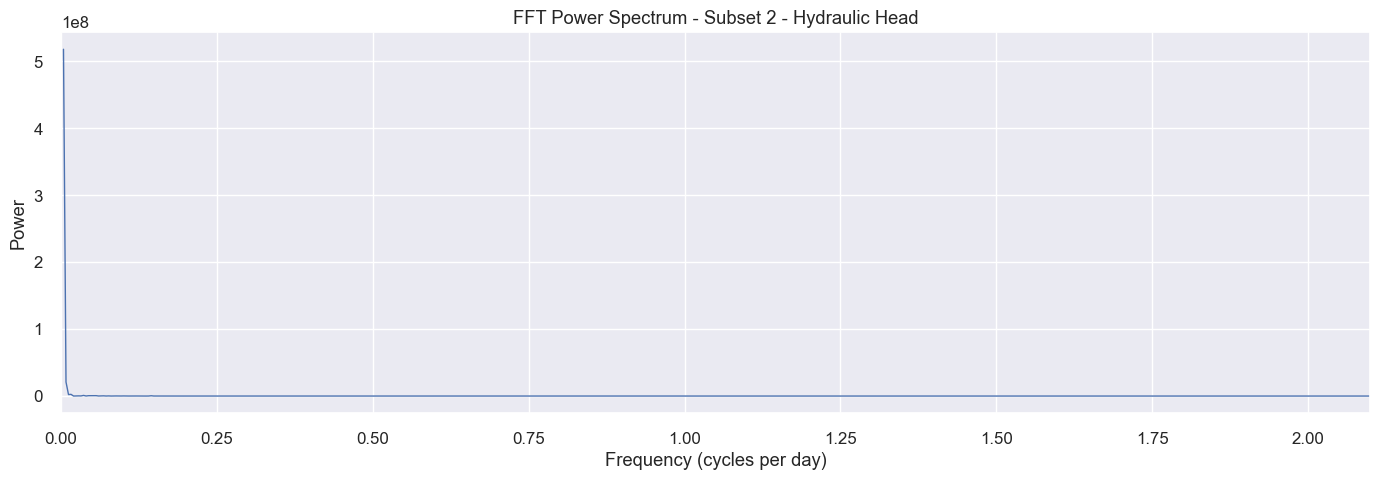

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Série de nível d'água
series_fft = data_ts["gmu_level_mH2O_compensado"].dropna()

if series_fft.empty:
    print("No data available for FFT.")
else:
    signal = series_fft.values
    n = len(signal)

    # Remove média (componente DC)
    signal_detrended = signal - np.mean(signal)

    # ----------------------------------------
    # FFT
    # ----------------------------------------
    fft_vals = np.fft.fft(signal_detrended)

    # Frequências em Hz
    fs = 1 / 1800  # Hz (30 min)
    fft_freq_hz = np.fft.fftfreq(n, d=1/fs)

    # Mantém apenas frequências positivas
    mask = fft_freq_hz > 0
    fft_freq_hz = fft_freq_hz[mask]
    fft_vals = fft_vals[mask]

    # Converte para ciclos por dia
    fft_freq_cpd = fft_freq_hz * 86400

    # Espectro de potência
    power = np.abs(fft_vals) ** 2

    # ----------------------------------------
    # Plot
    # ----------------------------------------
    plt.figure(figsize=(14, 5))
    plt.plot(fft_freq_cpd, power, linewidth=1)
    plt.xlabel("Frequency (cycles per day)")
    plt.ylabel("Power")
    plt.title("FFT Power Spectrum - Subset 2 - Hydraulic Head")
    plt.xlim(0, 2.1)   # <<< limite solicitado
    plt.tight_layout()
    plt.show()


In [21]:
import numpy as np
from scipy.signal import find_peaks

# ----------------------------------------
# Assumindo que você já tem:
# fft_freq_cpd
# power
# ----------------------------------------

# Energia total do espectro
total_energy = np.nansum(power)

# Normaliza pelo pico máximo (ajuda na detecção)
power_norm = power / np.nanmax(power)

# Detecta picos significativos
peaks, _ = find_peaks(
    power_norm,
    height=0.01,   # >= 1% do pico máximo
    distance=5
)

# Frequências e potências dos picos
peak_freqs = fft_freq_cpd[peaks]
peak_powers = power[peaks]

# Energia proporcional (% do total)
peak_energy_pct = 100 * peak_powers / total_energy

# Ordena por energia proporcional decrescente
sorted_idx = np.argsort(peak_energy_pct)[::-1]
peak_freqs = peak_freqs[sorted_idx]
peak_powers = peak_powers[sorted_idx]
peak_energy_pct = peak_energy_pct[sorted_idx]

# ----------------------------------------
# Exibe resultados
# ----------------------------------------
print("Spectral peaks – proportional energy contribution:")
for f, p_abs, e_pct in zip(
    peak_freqs[:10],
    peak_powers[:10],
    peak_energy_pct[:10]
):
    period_hours = 24 / f
    print(
        f"Frequency: {f:.4f} cpd | "
        f"Period: {period_hours:6.2f} h | "
        f"Power: {p_abs:.2e} | "
        f"Energy fraction: {e_pct:5.2f}%"
    )


Spectral peaks – proportional energy contribution:


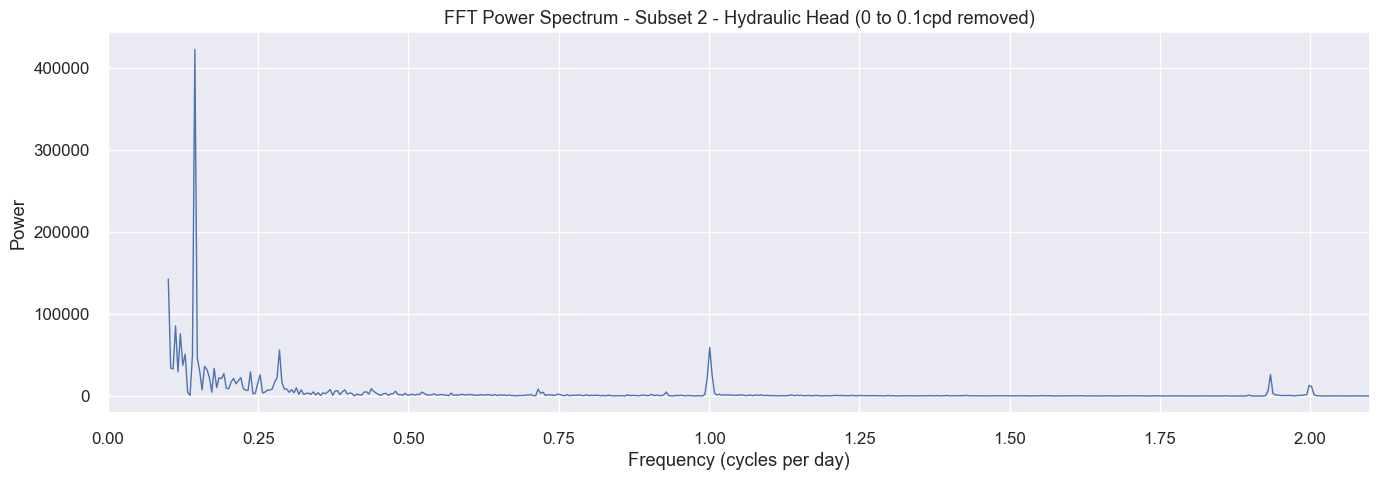

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Série de nível d'água
series_fft = data_ts["gmu_level_mH2O_compensado"].dropna()

if series_fft.empty:
    print("No data available for FFT.")
else:
    signal = series_fft.values
    n = len(signal)

    # Remove média (componente DC)
    signal_detrended = signal - np.mean(signal)

    # ----------------------------------------
    # FFT
    # ----------------------------------------
    fft_vals = np.fft.fft(signal_detrended)

    # Frequências em Hz
    fs = 1 / 1800  # Hz (30 min)
    fft_freq_hz = np.fft.fftfreq(n, d=1/fs)

    # Mantém apenas frequências positivas
    mask = fft_freq_hz > 0
    fft_freq_hz = fft_freq_hz[mask]
    fft_vals = fft_vals[mask]

    # Converte para ciclos por dia
    fft_freq_cpd = fft_freq_hz * 86400

    # Espectro de potência
    power = np.abs(fft_vals) ** 2

    # ----------------------------------------
    # Remove peak around 0.1479 cpd
    # ----------------------------------------
    f0 = 0.0        # frequência do pico (cpd)
    bandwidth = 0.1  # largura da banda removida (ajuste se necessário)

    band_mask = ~(
        (fft_freq_cpd >= (f0 - bandwidth)) &
        (fft_freq_cpd <= (f0 + bandwidth))
    )

    fft_freq_cpd_filt = fft_freq_cpd[band_mask]
    power_filt = power[band_mask]

    # ----------------------------------------
    # Plot
    # ----------------------------------------
    plt.figure(figsize=(14, 5))
    plt.plot(fft_freq_cpd_filt, power_filt, linewidth=1)
    plt.xlabel("Frequency (cycles per day)")
    plt.ylabel("Power")
    plt.title("FFT Power Spectrum - Subset 2 - Hydraulic Head (0 to 0.1cpd removed)")
    plt.xlim(0, 2.1)
    plt.tight_layout()
    plt.show()


In [23]:
import numpy as np
from scipy.signal import find_peaks

# ----------------------------------------
# Usa o espectro FILTRADO do Código 1:
# fft_freq_cpd_filt
# power_filt
# ----------------------------------------

# Energia total do espectro filtrado
total_energy_filt = np.nansum(power_filt)

# Normaliza pelo pico máximo (para detecção)
power_norm_filt = power_filt / np.nanmax(power_filt)

# Detecta picos significativos no espectro filtrado
peaks, _ = find_peaks(
    power_norm_filt,
    height=0.01,   # >= 1% do pico máximo
    distance=5
)

# Frequências e potências dos picos
peak_freqs = fft_freq_cpd_filt[peaks]
peak_powers = power_filt[peaks]

# Energia proporcional (% do total filtrado)
peak_energy_pct = 100 * peak_powers / total_energy_filt

# Ordena por energia proporcional decrescente
sorted_idx = np.argsort(peak_energy_pct)[::-1]
peak_freqs = peak_freqs[sorted_idx]
peak_powers = peak_powers[sorted_idx]
peak_energy_pct = peak_energy_pct[sorted_idx]

# ----------------------------------------
# Exibe resultados
# ----------------------------------------
print("Spectral peaks – proportional energy contribution (filtered spectrum):")
for f, p_abs, e_pct in zip(
    peak_freqs[:10],
    peak_powers[:10],
    peak_energy_pct[:10]
):
    period_hours = 24 / f
    print(
        f"Frequency: {f:.4f} cpd | "
        f"Period: {period_hours:6.2f} h | "
        f"Power: {p_abs:.2e} | "
        f"Energy fraction: {e_pct:5.2f}%"
    )


Spectral peaks – proportional energy contribution (filtered spectrum):
Frequency: 0.1447 cpd | Period: 165.82 h | Power: 4.22e+05 | Energy fraction: 18.34%
Frequency: 0.1126 cpd | Period: 213.20 h | Power: 8.55e+04 | Energy fraction:  3.71%
Frequency: 1.0011 cpd | Period:  23.97 h | Power: 5.92e+04 | Energy fraction:  2.57%
Frequency: 0.2855 cpd | Period:  84.08 h | Power: 5.61e+04 | Energy fraction:  2.43%
Frequency: 0.1769 cpd | Period: 135.67 h | Power: 3.37e+04 | Energy fraction:  1.46%
Frequency: 0.2372 cpd | Period: 101.18 h | Power: 2.94e+04 | Energy fraction:  1.28%
Frequency: 1.9338 cpd | Period:  12.41 h | Power: 2.62e+04 | Energy fraction:  1.14%
Frequency: 0.2091 cpd | Period: 114.80 h | Power: 2.15e+04 | Energy fraction:  0.93%
Frequency: 1.9982 cpd | Period:  12.01 h | Power: 1.30e+04 | Energy fraction:  0.56%
Frequency: 0.3136 cpd | Period:  76.53 h | Power: 1.00e+04 | Energy fraction:  0.44%


In [24]:
1 / 0.1126

8.880994671403197

 ## 5. Hydrogeological Variable Relationships



 Includes:



 - Correlation matrix

 - Pairwise plots

 - Cross-correlation (rain → water level, pressure → level, etc.)

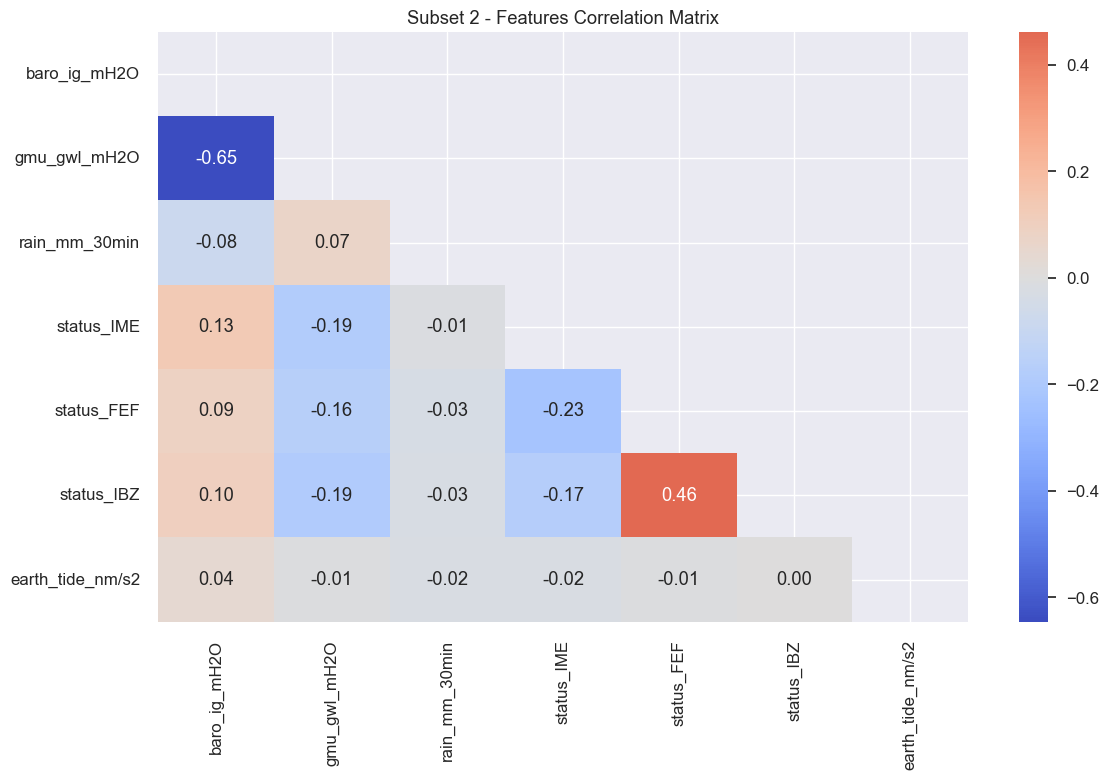

In [25]:
# matriz de correlação
corr = data_ts.corr()

# renomeação apenas para visualização
rename_map = {
    "pressao_mH2O_final": "baro_ig_mH2O",
    "gmu_level_mH2O_compensado": "gmu_gwl_mH2O",
    "chuva_mm_30min": "rain_mm_30min",
    "status_IMECC": "status_IME",
    "status_ZOOLOGIA": "status_IBZ"
}


corr_plot = corr.rename(index=rename_map, columns=rename_map)

# plot
plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_plot, dtype=bool))

sns.heatmap(
    corr_plot,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)
plt.title("Subset 2 - Features Correlation Matrix")
plt.tight_layout()
plt.show()


 ## 6. Hydrogeological Event Analysis



 Examples:



 - Rainfall events and corresponding groundwater response

 - Recharge delay analysis

 - Pumping influence on water level

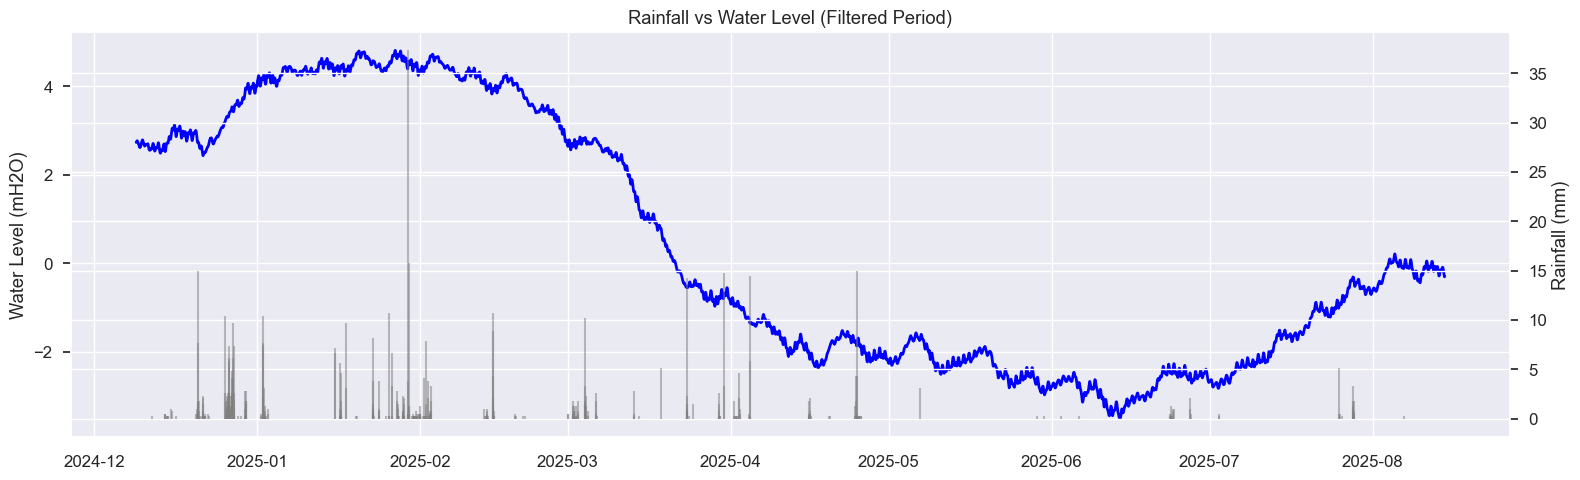

In [26]:
fig, ax1 = plt.subplots(figsize=(16, 5))

# Water level
ax1.plot(data_ts.index, data_ts["gmu_level_mH2O_compensado"], 
         color="blue", linewidth=2)
ax1.set_ylabel("Water Level (mH2O)")

# Rainfall as vertical spikes
ax2 = ax1.twinx()
ax2.vlines(
    data_ts.index, 
    ymin=0, ymax=data_ts["chuva_mm_30min"],
    color="gray", alpha=0.5
)
ax2.set_ylabel("Rainfall (mm)")

plt.title("Rainfall vs Water Level (Filtered Period)")
plt.tight_layout()
plt.show()


 ## 7. Sensor Consistency Analysis



 - Water level vs atmospheric pressure

 - Water level vs Earth tide

 - Check sensor drift or offsets

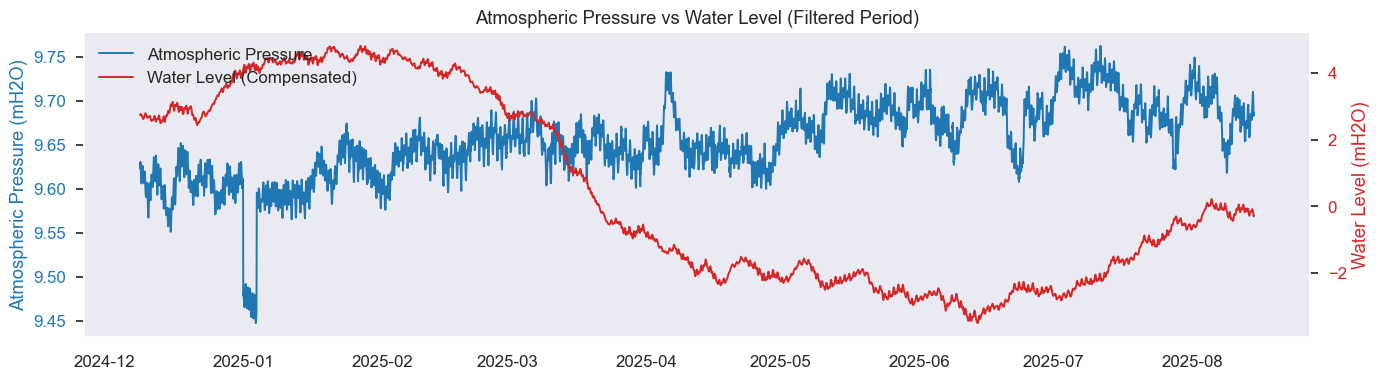

In [27]:
plt.figure(figsize=(14, 4))

ax1 = plt.gca()

# --- Eixo Y esquerdo (Pressão Barométrica) ---
ax1.plot(
    data_ts.index, 
    data_ts["pressao_mH2O_final"], 
    label="Atmospheric Pressure",
    linewidth=1.4,
    color="#1f77b4"
)
ax1.set_ylabel("Atmospheric Pressure (mH2O)", color="#1f77b4")
ax1.tick_params(axis='y', labelcolor="#1f77b4")

# Remover grid do eixo principal
ax1.grid(False)

# --- Eixo Y direito (Nível Compensado) ---
ax2 = ax1.twinx()
ax2.plot(
    data_ts.index, 
    data_ts["gmu_level_mH2O_compensado"], 
    label="Water Level (Compensated)",
    linewidth=1.4,
    color="#d62728"
)
ax2.set_ylabel("Water Level (mH2O)", color="#d62728")
ax2.tick_params(axis='y', labelcolor="#d62728")

# Garantir sem grid também no eixo secundário
ax2.grid(False)

# --- Título ---
plt.title("Atmospheric Pressure vs Water Level (Filtered Period)")

# --- Legendas combinadas ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
plt.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()


 ## 8. Exploratory Feature Engineering



 - Lag features

 - Moving averages

 - Rainfall accumulations

 - Weekday/weekend flags

In [28]:
data_fe = data_ts.copy()

# Example feature set
if "gmu_level_mH2O_compensado" in data_fe.columns:
    data_fe["lag_1h"] = data_fe["gmu_level_mH2O_compensado"].shift(2)
    data_fe["lag_6h"] = data_fe["gmu_level_mH2O_compensado"].shift(12)

if "chuva_mm_30min" in data_fe.columns:
    data_fe["rain_6h"] = data_fe["chuva_mm_30min"].rolling(12).sum()

data_fe["is_weekday"] = (data_fe.index.weekday < 5).astype(int)

data_fe.head()



,pressao_mH2O_final,gmu_level_mH2O_compensado,chuva_mm_30min,status_IMECC,status_FEF,status_ZOOLOGIA,earth_tide_nm/s2,lag_1h,lag_6h,rain_6h,is_weekday
date_time,,,,,,,,,,,
2024-12-08 23:00:00,9.622975,2.733855,0.0,0.0,0.0,0.0,-657.013,NaN,NaN,NaN,0
2024-12-08 23:30:00,9.624555,2.739275,0.0,0.0,0.0,0.0,-511.472,NaN,NaN,NaN,0
2024-12-09 00:00:00,9.626134,2.747036,0.0,0.0,0.0,0.0,-345.618,2.733855,NaN,NaN,1
2024-12-09 00:30:00,9.628297,2.750703,0.0,0.0,0.0,0.0,-168.715,2.739275,NaN,NaN,1
2024-12-09 01:00:00,9.630460,2.753790,0.0,0.0,0.0,0.0,9.259,2.747036,NaN,NaN,1


 ## 9. Visual Exploratory Analysis (EDA Visual)



 - Time-series overlays

 - Pairplots

 - Joint distributions

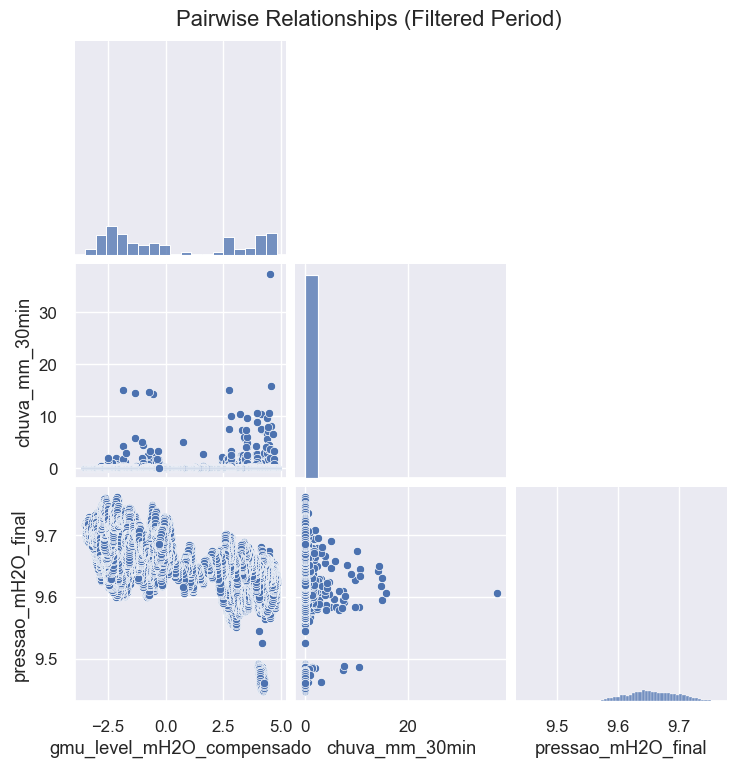

In [29]:
cols_for_pairplot = [
    col for col in ["gmu_level_mH2O_compensado", "chuva_mm_30min", "pressao_mH2O_final"]
    if col in data_ts.columns
]

if len(cols_for_pairplot) >= 2:
    sns.pairplot(
        data_ts[cols_for_pairplot].dropna(),
        corner=True,
    )
    plt.suptitle("Pairwise Relationships (Filtered Period)", y=1.02)
    plt.show()
else:
    print("Not enough numeric columns available for pairplot in the selected period.")


# # Cross-Correlation: Optimal Lag (Rain → Water Level)

C:\Users\peliz\AppData\Local\Temp\ipykernel_26120\2168330357.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  level = data_ts["gmu_level_mH2O_compensado"].fillna(method="ffill")


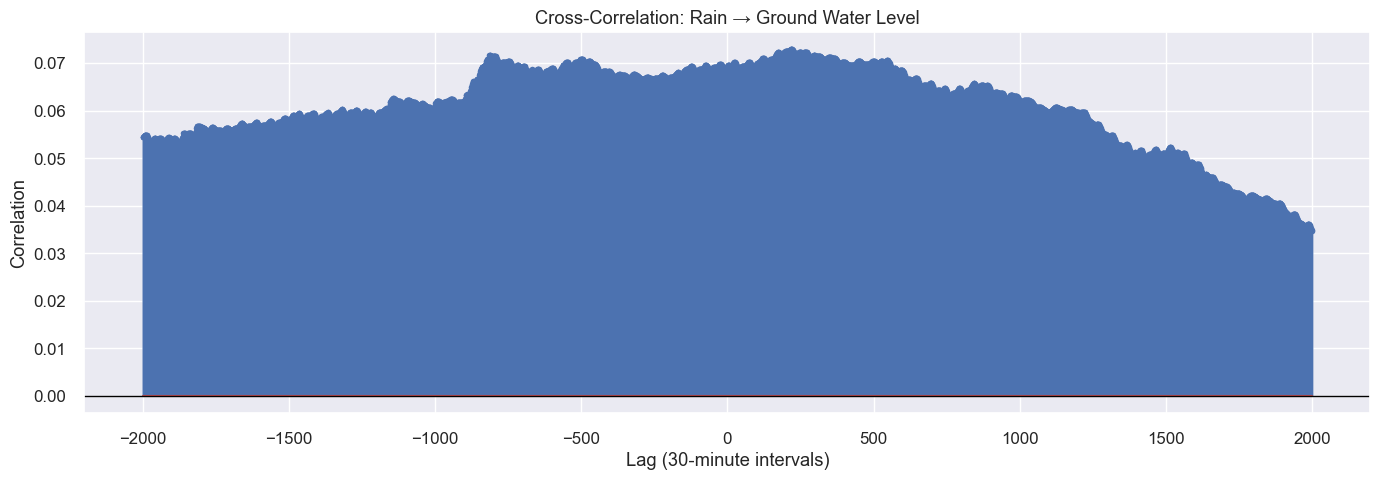

Best lag: 219 intervals
≈ 109.50 hours
≈ 4.56 days


In [30]:
# Select series (drop NaN to align signals)
rain = data_ts["chuva_mm_30min"].fillna(0)
level = data_ts["gmu_level_mH2O_compensado"].fillna(method="ffill")

max_lag = 2000   # 200 lags = 100h = ~4 days
lags = np.arange(-max_lag, max_lag + 1)

ccf = [np.corrcoef(rain.shift(lag).fillna(0), level)[0, 1] for lag in lags]

plt.figure(figsize=(14,5))

# Compatible stem plot
markerline, stemlines, baseline = plt.stem(lags, ccf)
plt.setp(stemlines, linewidth=1)
plt.setp(markerline, markersize=4)

plt.axhline(0, color='black', linewidth=1)
plt.title("Cross-Correlation: Rain → Ground Water Level")
plt.xlabel("Lag (30-minute intervals)")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()

best_lag = lags[np.argmax(ccf)]
print(f"Best lag: {best_lag} intervals")
print(f"≈ {best_lag * 0.5:.2f} hours")
print(f"≈ {best_lag / 48:.2f} days")

### Daily Aggregation: Rainfall Accumulation vs Mean Water Level

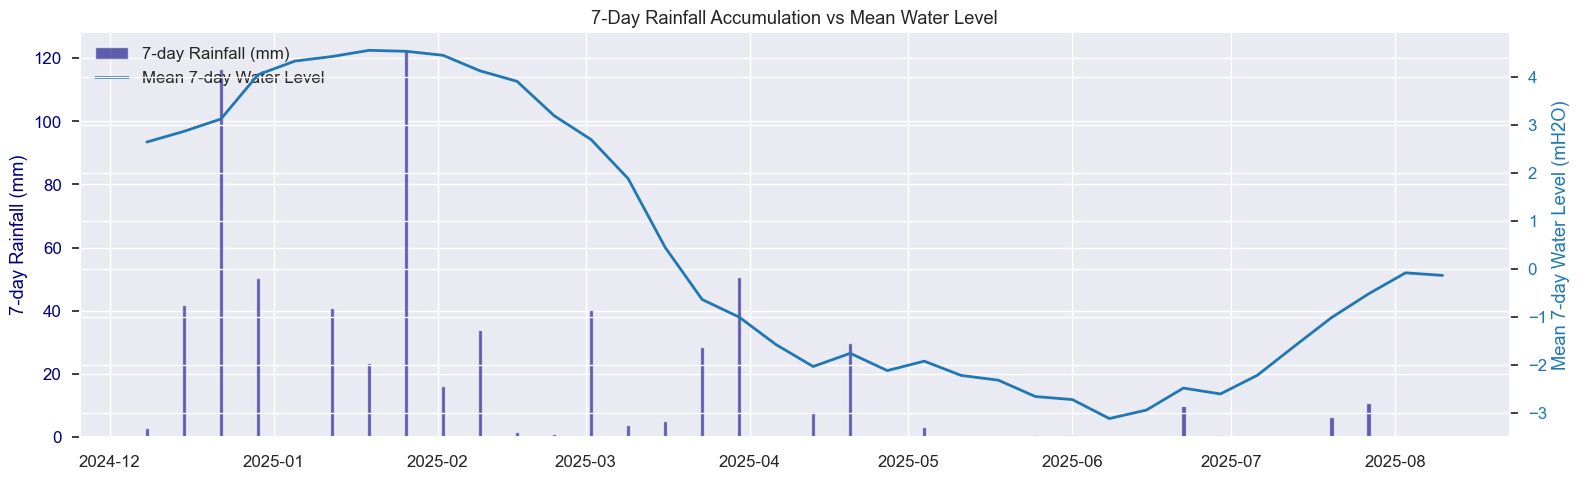

In [31]:
# %%
# 3-day aggregation (physical meaning preserved)
rain_7d = data_ts["chuva_mm_30min"].resample("7D").sum(min_count=1)
level_7d = data_ts["gmu_level_mH2O_compensado"].resample("7D").mean()

# Align time index
df_7d = pd.DataFrame({
    "rain_7d_mm": rain_7d,
    "level_7d_mH2O": level_7d
})

# Drop periods with no information at all
df_7d = df_7d.dropna(how="all")
# Plot
fig, ax1 = plt.subplots(figsize=(16, 5))

# --- Rainfall (dark blue) ---
ax1.bar(
    df_7d.index,
    df_7d["rain_7d_mm"],
    color="navy",
    alpha=0.6,
    label="7-day Rainfall (mm)"
)
ax1.set_ylabel("7-day Rainfall (mm)", color="navy")
ax1.tick_params(axis='y', labelcolor="navy")

# --- Water level (matplotlib default blue) ---
ax2 = ax1.twinx()
ax2.plot(
    df_7d.index,
    df_7d["level_7d_mH2O"],
    color="tab:blue",
    linewidth=2,
    label="Mean 7-day Water Level"
)
ax2.set_ylabel("Mean 7-day Water Level (mH2O)", color="tab:blue")
ax2.tick_params(axis='y', labelcolor="tab:blue")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("7-Day Rainfall Accumulation vs Mean Water Level")
plt.tight_layout()
plt.show()


### Cross-Correlation: Daily Rainfall vs Daily Mean Water Level

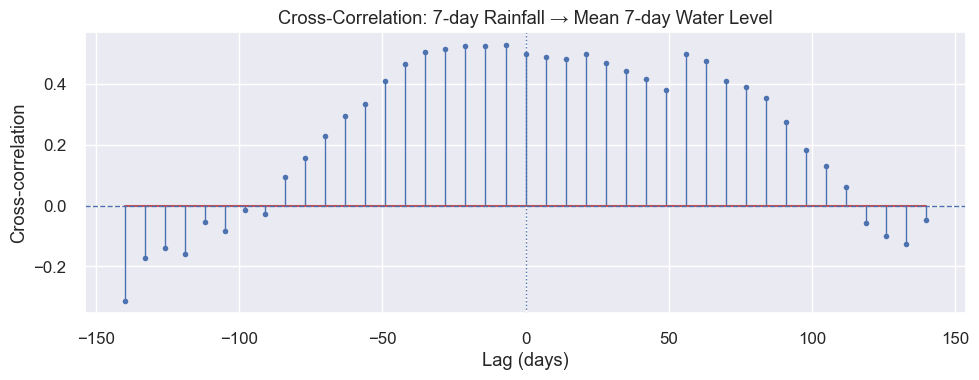

Maximum correlation at lag = -1 blocks
≈ -7 days


In [32]:
# %%
# Prepare aligned 3-day aggregated series
rain_3d = df_7d["rain_7d_mm"].fillna(0)
level_3d = df_7d["level_7d_mH2O"]

# Remove periods without level information
mask = level_7d.notna()
rain_7d = rain_7d[mask]
level_7d = level_7d[mask]

# Cross-correlation parameters
max_lag_blocks = 20   # ±20 blocks of 3 days (~±60 days)
lags = np.arange(-max_lag_blocks, max_lag_blocks + 1)

ccf = []
for lag in lags:
    if lag < 0:
        ccf.append(np.corrcoef(
            rain_7d[:lag],
            level_7d[-lag:]
        )[0, 1])
    elif lag > 0:
        ccf.append(np.corrcoef(
            rain_7d[lag:],
            level_7d[:-lag]
        )[0, 1])
    else:
        ccf.append(np.corrcoef(rain_7d, level_7d)[0, 1])
ccf = np.array(ccf)

# Convert lag blocks to physical days
lags_days = lags * 7

# Plot
plt.figure(figsize=(10, 4))

markerline, stemlines, baseline = plt.stem(lags_days, ccf)
plt.setp(stemlines, linewidth=1)
plt.setp(markerline, markersize=4)

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle=":", linewidth=1)
plt.xlabel("Lag (days)")
plt.ylabel("Cross-correlation")
plt.title("Cross-Correlation: 7-day Rainfall → Mean 7-day Water Level")
plt.tight_layout()
plt.show()

# Best lag (in blocks and days)
best_idx = np.nanargmax(ccf)
best_lag_blocks = lags[best_idx]
best_lag_days = best_lag_blocks * 7

print(f"Maximum correlation at lag = {best_lag_blocks} blocks")
print(f"≈ {best_lag_days} days")


In [33]:
# ----------------------------------------
# 1-day aggregation
# ----------------------------------------
rain_1d = data_ts["chuva_mm_30min"].resample("1D").sum(min_count=1)
level_1d = data_ts["gmu_level_mH2O_compensado"].resample("1D").mean()

df_1d = pd.DataFrame({
    "rain_1d_mm": rain_1d,
    "level_1d_mH2O": level_1d
}).dropna(how="all")


# ----------------------------------------
# 7-day aggregation
# ----------------------------------------
rain_7d = data_ts["chuva_mm_30min"].resample("7D").sum(min_count=1)
level_7d = data_ts["gmu_level_mH2O_compensado"].resample("7D").mean()

df_7d = pd.DataFrame({
    "rain_7d_mm": rain_7d,
    "level_7d_mH2O": level_7d
}).dropna(how="all")


In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def plot_ccf(rain, level, window_days, max_lag_blocks):
    """
    Plot cross-correlation between rainfall and groundwater level
    considering only non-negative lags (rain precedes level).
    """

    # Align and drop NaNs jointly
    df = pd.DataFrame({
        "rain": rain,
        "level": level
    }).dropna()

    if df.empty:
        print("No overlapping data available for CCF.")
        return

    rain = df["rain"].values
    level = df["level"].values

    # Only non-negative lags
    lags = np.arange(0, max_lag_blocks + 1)
    ccf = []

    for lag in lags:
        if lag == 0:
            r = rain
            l = level
        else:
            r = rain[:-lag]
            l = level[lag:]

        if len(r) < 3:
            ccf.append(np.nan)
        else:
            ccf.append(np.corrcoef(r, l)[0, 1])

    ccf = np.array(ccf)
    lags_days = lags * window_days

    # ----------------------------
    # Plot
    # ----------------------------
    plt.figure(figsize=(10, 4))

    markerline, stemlines, baseline = plt.stem(
        lags_days,
        ccf,
        basefmt=" "
    )
    plt.setp(stemlines, linewidth=1)
    plt.setp(markerline, markersize=4)

    plt.axhline(0, linestyle="--", linewidth=1, color="black")
    plt.axvline(0, linestyle=":", linewidth=1, color="black")

    plt.xlabel("Lag (days)")
    plt.ylabel("Cross-correlation")
    plt.title(
        f"Subset 2 – Cross-Correlation: Precipitation → Hydraulic Head "
        f"({window_days}-day aggregation)"
    )

    plt.tight_layout()
    plt.show()

    # ----------------------------
    # Best lag
    # ----------------------------
    if np.all(np.isnan(ccf)):
        print("No valid correlation values.")
        return

    best_idx = np.nanargmax(ccf)
    best_lag_blocks = lags[best_idx]
    best_lag_days = lags_days[best_idx]

    print(f"Maximum correlation at lag = {best_lag_blocks} blocks")
    print(f"≈ {best_lag_days} days")


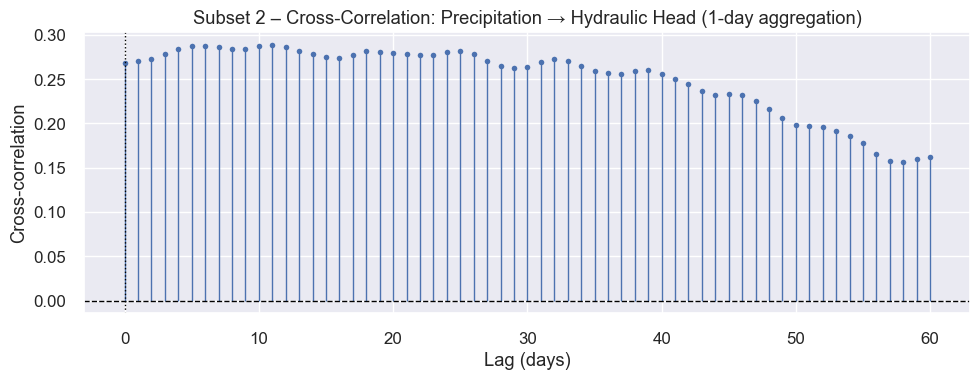

Maximum correlation at lag = 11 blocks
≈ 11 days


In [35]:
plot_ccf(
    rain=df_1d["rain_1d_mm"],
    level=df_1d["level_1d_mH2O"],
    window_days=1,
    max_lag_blocks=60   # ±30 dias
)


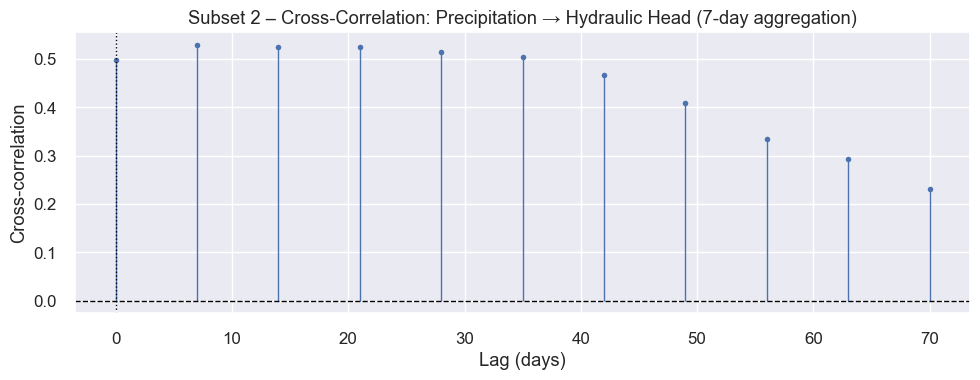

Maximum correlation at lag = 1 blocks
≈ 7 days


In [36]:
plot_ccf(
    rain=df_7d["rain_7d_mm"],
    level=df_7d["level_7d_mH2O"],
    window_days=7,
    max_lag_blocks=10   # ±140 dias
)
